# Trader Performance vs Market Sentiment - Hyperliquid Analysis

**Assignment:** Data Science / Analytics Intern - Round 0 (Primetrade.ai)

This notebook analyzes how Bitcoin market sentiment (Fear/Greed Index) relates to
trader behavior and performance on Hyperliquid, using ~211K historical trade
records across 32 accounts (May 2023 - May 2025).

**Structure**
- Part A - Data preparation (loading, cleaning, alignment, key metrics)
- Part B - Analysis (performance vs sentiment, behavior vs sentiment, trader segments, insights)
- Part C - Actionable strategy recommendations
- Bonus - Trader archetype clustering + a simple next-day profitability model

**A note on scope:** the raw dataset does not include an explicit `leverage` or
account-equity/margin field, so true leverage multiples cannot be computed. We use
trade size (USD) and total volume as intensity proxies instead, and call this out
explicitly wherever it matters.

In [1]:
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score

sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 160)

## Part A - Data Preparation

### A1. Load both datasets and document shape / quality

In [2]:
trades = pd.read_csv('data/historical_data__1_.csv')
fg = pd.read_csv('data/fear_greed_index__1_.csv')

print("Historical trades:", trades.shape, "-> (rows, columns)")
print("Fear/Greed index :", fg.shape, "-> (rows, columns)")

Historical trades: (211224, 16) -> (rows, columns)
Fear/Greed index : (2644, 4) -> (rows, columns)


In [3]:
print("=== Trades: dtypes ===")
print(trades.dtypes)
print("\n=== Trades: missing values ===")
print(trades.isnull().sum())
print("\n=== Trades: duplicate rows ===", trades.duplicated().sum())

=== Trades: dtypes ===
Account                 str
Coin                    str
Execution Price     float64
Size Tokens         float64
Size USD            float64
Side                    str
Timestamp IST           str
Start Position      float64
Direction               str
Closed PnL          float64
Transaction Hash        str
Order ID              int64
Crossed                bool
Fee                 float64
Trade ID            float64
Timestamp           float64
dtype: object

=== Trades: missing values ===
Account             0
Coin                0
Execution Price     0
Size Tokens         0
Size USD            0
Side                0
Timestamp IST       0
Start Position      0
Direction           0
Closed PnL          0
Transaction Hash    0
Order ID            0
Crossed             0
Fee                 0
Trade ID            0
Timestamp           0
dtype: int64



=== Trades: duplicate rows === 0


In [4]:
print("=== Fear/Greed: dtypes ===")
print(fg.dtypes)
print("\n=== Fear/Greed: missing values ===")
print(fg.isnull().sum())
print("\n=== Fear/Greed: duplicate rows ===", fg.duplicated().sum())
print("\n=== Classification value counts ===")
print(fg['classification'].value_counts())

=== Fear/Greed: dtypes ===
timestamp         int64
value             int64
classification      str
date                str
dtype: object

=== Fear/Greed: missing values ===
timestamp         0
value             0
classification    0
date              0
dtype: int64

=== Fear/Greed: duplicate rows === 0

=== Classification value counts ===
classification
Fear             781
Greed            633
Extreme Fear     508
Neutral          396
Extreme Greed    326
Name: count, dtype: int64


**Observations**
- Trades: 211,224 rows x 16 columns, **zero missing values, zero duplicates**. Very clean.
- Fear/Greed index: 2,644 rows x 4 columns, **zero missing values, zero duplicates**, and
  covers 2018-02-01 through 2025-05-02 (much longer history than the trade log).
- The trade log spans **32 unique accounts** and **246 distinct coins**, from
  2023-05-01 to 2025-05-01 (with the bulk of activity concentrated from late 2024
  through April 2025).
- `Closed PnL` is populated on every row, but only *closing* trades (Close Long /
  Close Short / Sell / Buy-to-close) actually realize non-zero PnL — opening trades
  correctly show `0`. This is expected and is handled explicitly below (win rate is
  computed only over realized/closing trades, not all trades).
- There is **no leverage or account-equity column** in the raw data, despite the
  assignment brief mentioning it — we substitute trade size (USD) and account
  trading volume as an intensity proxy and flag this limitation throughout.

### A2. Convert timestamps and align datasets by date

In [5]:
trades['dt'] = pd.to_datetime(trades['Timestamp IST'], format='%d-%m-%Y %H:%M')
trades['date'] = trades['dt'].dt.normalize()

fg['date'] = pd.to_datetime(fg['date'])

def bucket(c):
    """Collapse the 5-way Fear/Greed classification into 3 buckets for the core analysis."""
    if c in ('Fear', 'Extreme Fear'):
        return 'Fear'
    elif c in ('Greed', 'Extreme Greed'):
        return 'Greed'
    return 'Neutral'

fg['sentiment'] = fg['classification'].apply(bucket)

date_min, date_max = trades['date'].min(), trades['date'].max()
print(f"Trade data window: {date_min.date()} to {date_max.date()}")
print(f"Unique trading days in trade log: {trades['date'].nunique()}")

trades = trades.merge(fg[['date', 'classification', 'sentiment', 'value']], on='date', how='left')
print(f"\nTrades with no matching sentiment day: {trades['sentiment'].isnull().sum()} "
      f"(out of {len(trades)}) -> dropped")

trades_matched = trades.dropna(subset=['sentiment']).copy()
print(f"Trades retained for analysis: {len(trades_matched):,}")

Trade data window: 2023-05-01 to 2025-05-01
Unique trading days in trade log: 480



Trades with no matching sentiment day: 6 (out of 211224) -> dropped


Trades retained for analysis: 211,218


### A3. Derive key metrics

We build an **Account x Day** panel (2,340 account-days across 32 accounts) with:
- daily realized PnL, win rate (over realized/closing trades only)
- number of trades, average trade size, total volume
- long vs short "open" counts -> long/short ratio and net long bias
- the day's Fear/Greed sentiment bucket and raw index value

In [6]:
trades_matched['is_long_open'] = trades_matched['Direction'] == 'Open Long'
trades_matched['is_short_open'] = trades_matched['Direction'] == 'Open Short'
trades_matched['is_realized'] = trades_matched['Closed PnL'] != 0

grp = trades_matched.groupby(['Account', 'date'])
daily = grp.agg(
    daily_pnl=('Closed PnL', 'sum'),
    n_trades=('Closed PnL', 'count'),
    n_realized=('is_realized', 'sum'),
    n_wins=('Closed PnL', lambda x: (x > 0).sum()),
    n_losses=('Closed PnL', lambda x: (x < 0).sum()),
    avg_trade_size_usd=('Size USD', 'mean'),
    total_volume_usd=('Size USD', 'sum'),
    n_long_open=('is_long_open', 'sum'),
    n_short_open=('is_short_open', 'sum'),
    total_fee=('Fee', 'sum'),
    sentiment=('sentiment', 'first'),
    classification=('classification', 'first'),
    fg_value=('value', 'first'),
).reset_index()

daily['win_rate'] = np.where(daily['n_realized'] > 0, daily['n_wins'] / daily['n_realized'], np.nan)
daily['long_short_ratio'] = np.where(daily['n_short_open'] > 0,
                                      daily['n_long_open'] / daily['n_short_open'], np.nan)
daily['net_long_bias'] = daily['n_long_open'] - daily['n_short_open']

print("Account x Day panel:", daily.shape)
daily.head()

Account x Day panel: (2340, 18)


,Account,date,daily_pnl,n_trades,n_realized,n_wins,n_losses,avg_trade_size_usd,total_volume_usd,n_long_open,n_short_open,total_fee,sentiment,classification,fg_value,win_rate,long_short_ratio,net_long_bias
0,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-11,0.0,177,0,0,0,5089.718249,900880.13,0,177,167.796055,Greed,Extreme Greed,76.0,NaN,0.0,-177
1,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-17,0.0,68,0,0,0,7976.664412,542413.18,0,68,67.883615,Greed,Extreme Greed,90.0,NaN,0.0,-68
2,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-18,0.0,40,0,0,0,23734.500000,949380.00,0,40,94.937983,Greed,Extreme Greed,83.0,NaN,0.0,-40
3,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-22,-21227.0,12,12,0,12,28186.666667,338240.00,0,0,33.823995,Greed,Extreme Greed,94.0,0.0,NaN,0
4,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-26,1603.1,27,12,12,0,17248.148148,465700.00,0,15,104.622490,Greed,Extreme Greed,79.0,1.0,0.0,-15


## Part B - Analysis

### B1. Does performance differ between Fear vs Greed days?

In [7]:
order = ['Fear', 'Neutral', 'Greed']
colors = ['#c0392b', '#7f8c8d', '#27ae60']

sent_perf = daily.groupby('sentiment').agg(
    n_account_days=('daily_pnl', 'count'),
    mean_daily_pnl=('daily_pnl', 'mean'),
    median_daily_pnl=('daily_pnl', 'median'),
    total_pnl=('daily_pnl', 'sum'),
    mean_win_rate=('win_rate', 'mean'),
    pct_profitable_days=('daily_pnl', lambda x: (x > 0).mean()),
    mean_trades_per_day=('n_trades', 'mean'),
).reindex(order)
sent_perf

,n_account_days,mean_daily_pnl,median_daily_pnl,total_pnl,mean_win_rate,pct_profitable_days,mean_trades_per_day
sentiment,,,,,,,
Fear,790,5185.146443,122.737038,4.096266e+06,0.842294,0.603797,105.363291
Neutral,376,3438.618818,167.551743,1.292921e+06,0.835721,0.622340,100.228723
Greed,1174,4144.208334,265.247725,4.865301e+06,0.856307,0.643101,76.912266


In [8]:
# Drawdown proxy: running peak-to-trough of cumulative PnL per account, split by the
# sentiment on each day
daily_sorted = daily.sort_values(['Account', 'date']).copy()
daily_sorted['cum_pnl'] = daily_sorted.groupby('Account')['daily_pnl'].cumsum()
daily_sorted['running_peak'] = daily_sorted.groupby('Account')['cum_pnl'].cummax()
daily_sorted['drawdown'] = daily_sorted['cum_pnl'] - daily_sorted['running_peak']
dd_by_sent = daily_sorted.groupby('sentiment')['drawdown'].mean().reindex(order)
print("Average drawdown proxy by sentiment (USD, more negative = deeper):")
print(dd_by_sent)

Average drawdown proxy by sentiment (USD, more negative = deeper):
sentiment
Fear      -8863.193211
Neutral   -9431.377301
Greed     -8892.618794
Name: drawdown, dtype: float64


In [9]:
# Statistical significance check (Mann-Whitney U — robust to the heavy skew in PnL)
fear_pnl = daily.loc[daily['sentiment'] == 'Fear', 'daily_pnl'].dropna()
greed_pnl = daily.loc[daily['sentiment'] == 'Greed', 'daily_pnl'].dropna()
u_stat, p_val = stats.mannwhitneyu(fear_pnl, greed_pnl, alternative='two-sided')
print(f"Fear vs Greed daily PnL — Mann-Whitney U={u_stat:.0f}, p={p_val:.4f}")

fear_wr = daily.loc[daily['sentiment'] == 'Fear', 'win_rate'].dropna()
greed_wr = daily.loc[daily['sentiment'] == 'Greed', 'win_rate'].dropna()
u2, p2 = stats.mannwhitneyu(fear_wr, greed_wr, alternative='two-sided')
print(f"Fear vs Greed win rate  — Mann-Whitney U={u2:.0f}, p={p2:.4f}")

Fear vs Greed daily PnL — Mann-Whitney U=440966, p=0.0618
Fear vs Greed win rate  — Mann-Whitney U=248690, p=0.2644


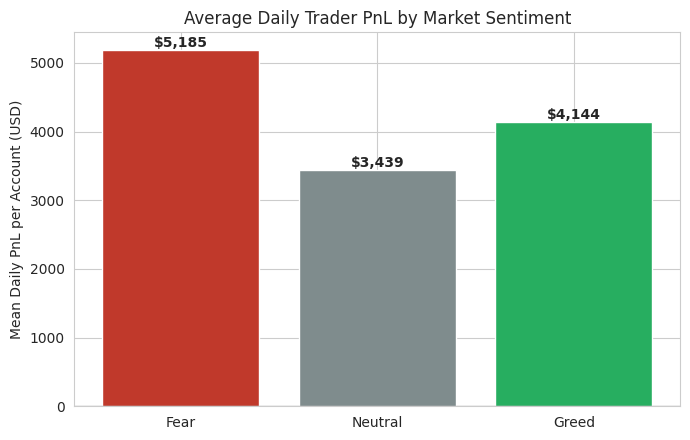

In [10]:
fig, ax = plt.subplots(figsize=(7, 4.5))
vals = sent_perf.loc[order, 'mean_daily_pnl']
bars = ax.bar(order, vals, color=colors)
ax.axhline(0, color='black', linewidth=0.8)
ax.set_ylabel('Mean Daily PnL per Account (USD)')
ax.set_title('Average Daily Trader PnL by Market Sentiment')
for b, v in zip(bars, vals):
    ax.annotate(f'${v:,.0f}', (b.get_x() + b.get_width()/2, v),
                ha='center', va='bottom' if v >= 0 else 'top', fontsize=10, fontweight='bold')
plt.tight_layout()
plt.show()

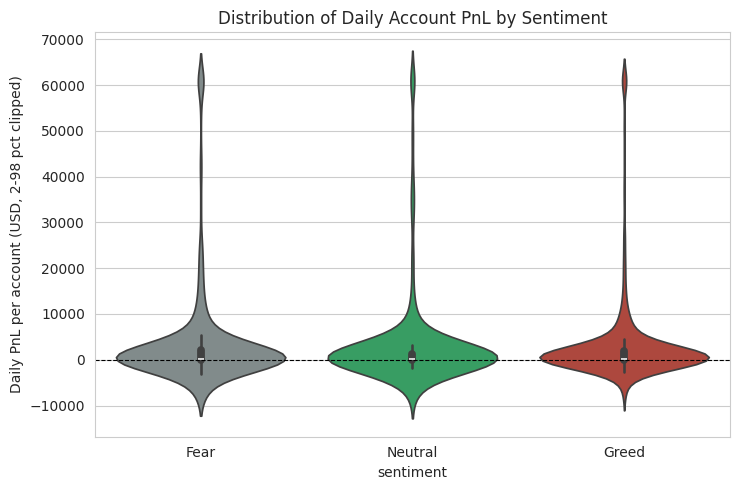

In [11]:
fig, ax = plt.subplots(figsize=(7.5, 5))
clip_daily = daily.copy()
lo, hi = clip_daily['daily_pnl'].quantile([0.02, 0.98])
clip_daily['daily_pnl_clipped'] = clip_daily['daily_pnl'].clip(lo, hi)
sns.violinplot(data=clip_daily, x='sentiment', y='daily_pnl_clipped', order=order, hue='sentiment',
                palette=colors, legend=False, ax=ax)
ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
ax.set_ylabel('Daily PnL per account (USD, 2-98 pct clipped)')
ax.set_title('Distribution of Daily Account PnL by Sentiment')
plt.tight_layout()
plt.show()

**Reading the numbers:** the *mean* daily PnL looks highest on Fear days, but that is
driven by a handful of very large winning trades (the distribution is extremely
right-skewed — note the std of daily PnL is ~$900 vs a median trade PnL of $0).
The **median** daily PnL and the **% of profitable account-days** both favor **Greed**
days (median ~$265 vs ~$123 on Fear days; 64.3% vs 60.4% profitable days), and the
Mann-Whitney tests show the Fear-vs-Greed PnL gap is only borderline significant
(p≈0.06) and the win-rate gap is not significant (p≈0.26) at conventional
thresholds. **Takeaway: on a typical day, traders in this sample do modestly better
during Greed regimes, but a small number of outsized wins during Fear regimes pull
the average up — performance is not cleanly "better" in one regime, it's *shaped
differently*.**

### B2. Do traders change behavior based on sentiment?

In [12]:
behavior = daily.groupby('sentiment').agg(
    mean_trades_per_day=('n_trades', 'mean'),
    mean_trade_size_usd=('avg_trade_size_usd', 'mean'),
    mean_volume_usd=('total_volume_usd', 'mean'),
    mean_long_short_ratio=('long_short_ratio', 'mean'),
    mean_net_long_bias=('net_long_bias', 'mean'),
).reindex(order)
behavior

,mean_trades_per_day,mean_trade_size_usd,mean_volume_usd,mean_long_short_ratio,mean_net_long_bias
sentiment,,,,,
Fear,105.363291,8529.859802,756720.318013,2.222829,13.630380
Neutral,100.228723,6963.694861,479367.189043,1.357632,10.289894
Greed,76.912266,5954.632633,351829.352036,1.300493,-3.818569


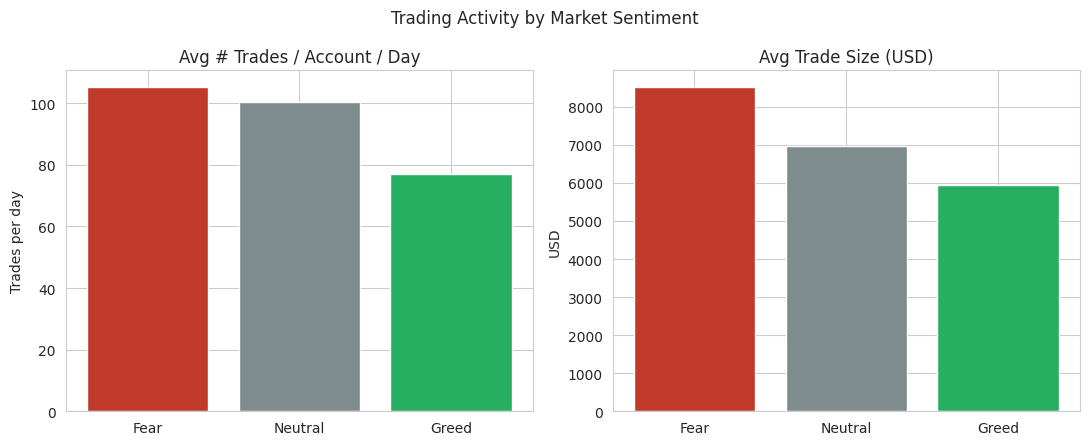

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
axes[0].bar(order, behavior['mean_trades_per_day'], color=colors)
axes[0].set_title('Avg # Trades / Account / Day')
axes[0].set_ylabel('Trades per day')
axes[1].bar(order, behavior['mean_trade_size_usd'], color=colors)
axes[1].set_title('Avg Trade Size (USD)')
axes[1].set_ylabel('USD')
plt.suptitle('Trading Activity by Market Sentiment')
plt.tight_layout()
plt.show()

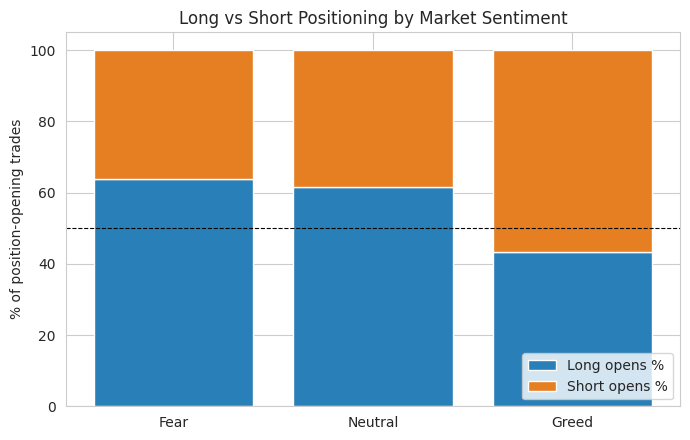

In [14]:
fig, ax = plt.subplots(figsize=(7, 4.5))
long_pct = daily.groupby('sentiment').apply(
    lambda d: d['n_long_open'].sum() / (d['n_long_open'].sum() + d['n_short_open'].sum()) * 100
).reindex(order)
short_pct = 100 - long_pct
ax.bar(order, long_pct, label='Long opens %', color='#2980b9')
ax.bar(order, short_pct, bottom=long_pct, label='Short opens %', color='#e67e22')
ax.axhline(50, color='black', linewidth=0.8, linestyle='--')
ax.set_ylabel('% of position-opening trades')
ax.set_title('Long vs Short Positioning by Market Sentiment')
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()

**Reading the numbers:** traders are clearly **more active and more aggressive
during Fear**: ~105 trades/account/day and an average trade size of ~$8.5K, versus
only ~77 trades/day and ~$6.0K average size during Greed — roughly 2x the average
daily volume per account ($757K vs $352K). They are also **much more long-biased
during Fear** (long/short open ratio ≈2.2 vs ≈1.3 in Greed), consistent with
"buy-the-dip" / contrarian behavior. Interestingly, the **net long bias flips
slightly negative during Greed** (more short opens than long opens on net),
suggesting some traders fade rallies rather than chase them.

### B3. Trader segmentation

We build three account-level segmentations and see how each behaves across
sentiment regimes. (Recall: no leverage field exists, so "size" segments are based
on average trade size in USD as an intensity proxy.)

In [15]:
acct = daily.groupby('Account').agg(
    total_pnl=('daily_pnl', 'sum'),
    active_days=('date', 'nunique'),
    total_trades=('n_trades', 'sum'),
    avg_trade_size=('avg_trade_size_usd', 'mean'),
    total_volume=('total_volume_usd', 'sum'),
    avg_daily_pnl=('daily_pnl', 'mean'),
    std_daily_pnl=('daily_pnl', 'std'),
    win_rate=('win_rate', 'mean'),
    pct_profitable_days=('daily_pnl', lambda x: (x > 0).mean()),
).reset_index()
acct['trades_per_active_day'] = acct['total_trades'] / acct['active_days']

size_terciles = acct['avg_trade_size'].quantile([1/3, 2/3]).values
acct['size_segment'] = acct['avg_trade_size'].apply(
    lambda x: 'Small size' if x <= size_terciles[0] else ('Mid size' if x <= size_terciles[1] else 'Large size'))

freq_terciles = acct['trades_per_active_day'].quantile([1/3, 2/3]).values
acct['freq_segment'] = acct['trades_per_active_day'].apply(
    lambda x: 'Infrequent' if x <= freq_terciles[0] else ('Moderate' if x <= freq_terciles[1] else 'Frequent'))

acct['consistency_segment'] = np.where(
    acct['pct_profitable_days'] >= acct['pct_profitable_days'].median(), 'Consistent winner', 'Inconsistent')

print(acct['size_segment'].value_counts(), '\n')
print(acct['freq_segment'].value_counts(), '\n')
print(acct['consistency_segment'].value_counts())

size_segment
Large size    11
Small size    11
Mid size      10
Name: count, dtype: int64 

freq_segment
Frequent      11
Infrequent    11
Moderate      10
Name: count, dtype: int64 

consistency_segment
Consistent winner    16
Inconsistent         16
Name: count, dtype: int64


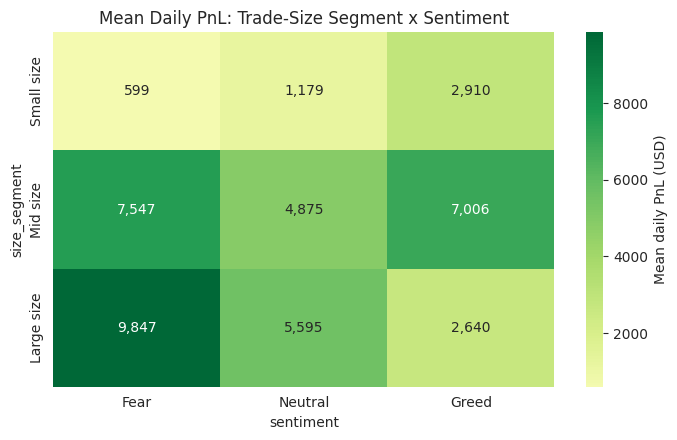

In [16]:
daily_seg = daily.merge(acct[['Account', 'size_segment', 'freq_segment', 'consistency_segment']],
                         on='Account', how='left')

seg1 = daily_seg.groupby(['size_segment', 'sentiment'])['daily_pnl'].mean().unstack().reindex(
    ['Small size', 'Mid size', 'Large size'])[order]
seg2 = daily_seg.groupby(['freq_segment', 'sentiment'])['daily_pnl'].mean().unstack().reindex(
    ['Infrequent', 'Moderate', 'Frequent'])[order]
seg3 = daily_seg.groupby(['consistency_segment', 'sentiment'])['daily_pnl'].mean().unstack()[order]

fig, ax = plt.subplots(figsize=(7, 4.5))
sns.heatmap(seg1, annot=True, fmt=',.0f', cmap='RdYlGn', center=0, ax=ax,
            cbar_kws={'label': 'Mean daily PnL (USD)'})
ax.set_title('Mean Daily PnL: Trade-Size Segment x Sentiment')
plt.tight_layout()
plt.show()

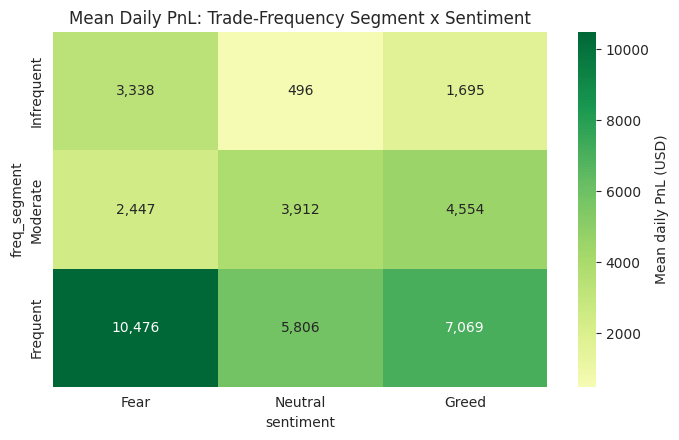

In [17]:
fig, ax = plt.subplots(figsize=(7, 4.5))
sns.heatmap(seg2, annot=True, fmt=',.0f', cmap='RdYlGn', center=0, ax=ax,
            cbar_kws={'label': 'Mean daily PnL (USD)'})
ax.set_title('Mean Daily PnL: Trade-Frequency Segment x Sentiment')
plt.tight_layout()
plt.show()

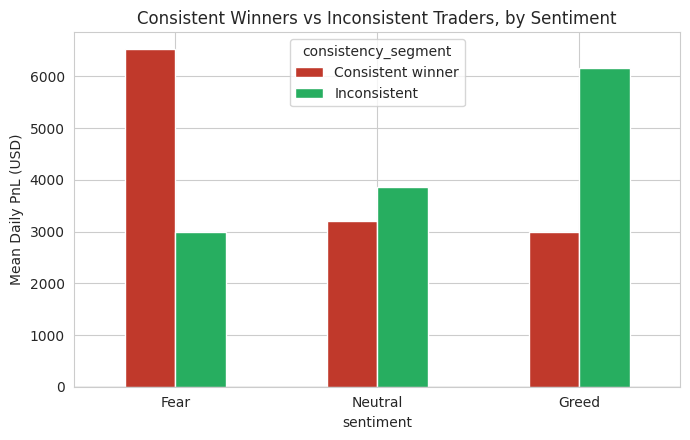

In [18]:
fig, ax = plt.subplots(figsize=(7, 4.5))
seg3.T.plot(kind='bar', ax=ax, color=['#c0392b', '#27ae60'])
ax.axhline(0, color='black', linewidth=0.8)
ax.set_ylabel('Mean Daily PnL (USD)')
ax.set_title('Consistent Winners vs Inconsistent Traders, by Sentiment')
ax.set_xticklabels(order, rotation=0)
plt.tight_layout()
plt.show()

**Key segment insight:** **large-size and consistently-profitable traders earn their
best days during Fear** (Large size: ~$9.8K mean daily PnL in Fear vs ~$2.6K in
Greed; Consistent winners: ~$6.5K in Fear vs ~$3.0K in Greed), while
**inconsistent traders spike specifically during Greed** (~$6.2K vs ~$3.0K in
Fear) — a pattern consistent with disciplined, larger traders capitalizing on
fear-driven mispricings, while less disciplined traders get their best (and likely
most fragile) results chasing momentum in euphoric markets.

## Bonus - Trader archetype clustering (KMeans)

In [19]:
feat_cols = ['avg_trade_size', 'trades_per_active_day', 'win_rate', 'pct_profitable_days', 'total_volume']
X = acct[feat_cols].fillna(acct[feat_cols].median())
Xs = StandardScaler().fit_transform(X)

km = KMeans(n_clusters=3, random_state=42, n_init=10)
acct['archetype_cluster'] = km.fit_predict(Xs)

cluster_profile = acct.groupby('archetype_cluster')[feat_cols + ['total_pnl']].mean().round(2)

whale_cluster = cluster_profile['avg_trade_size'].idxmax()
scalper_cluster = cluster_profile['trades_per_active_day'].idxmax()
labels = {}
for c in cluster_profile.index:
    if c == whale_cluster and c != scalper_cluster:
        labels[c] = 'Whale / Position Trader'
    elif c == scalper_cluster:
        labels[c] = 'High-Frequency Scalper'
    else:
        labels[c] = 'Retail / Casual Trader'
acct['archetype'] = acct['archetype_cluster'].map(labels)

print(acct.groupby('archetype')[feat_cols + ['total_pnl']].mean().round(2))
print("\nCounts:\n", acct['archetype'].value_counts())

                         avg_trade_size  trades_per_active_day  win_rate  pct_profitable_days  total_volume  total_pnl
archetype                                                                                                             
High-Frequency Scalper          2929.73                 218.56      0.85                 0.79  2.836142e+07  293287.78
Retail / Casual Trader          6888.10                  51.28      0.83                 0.44  1.097384e+07  268240.18
Whale / Position Trader        26329.29                 142.54      0.86                 0.63  1.476634e+08  557314.73

Counts:
 archetype
Retail / Casual Trader     18
High-Frequency Scalper      9
Whale / Position Trader     5
Name: count, dtype: int64


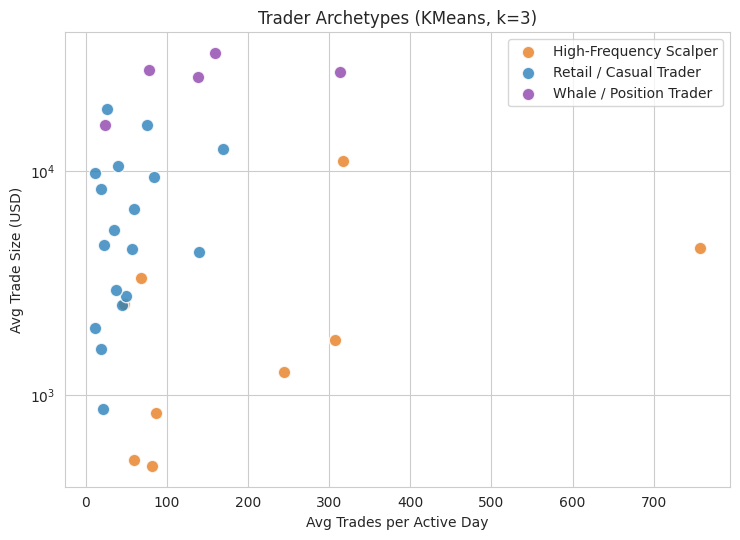

In [20]:
fig, ax = plt.subplots(figsize=(7.5, 5.5))
palette = {'Whale / Position Trader': '#8e44ad', 'High-Frequency Scalper': '#e67e22',
           'Retail / Casual Trader': '#2980b9'}
for a, sub in acct.groupby('archetype'):
    ax.scatter(sub['trades_per_active_day'], sub['avg_trade_size'], s=80, label=a,
               color=palette.get(a, 'gray'), alpha=0.8, edgecolor='white')
ax.set_xlabel('Avg Trades per Active Day')
ax.set_ylabel('Avg Trade Size (USD)')
ax.set_yscale('log')
ax.set_title('Trader Archetypes (KMeans, k=3)')
ax.legend()
plt.tight_layout()
plt.show()

Three natural archetypes emerge: a small group of **Whales / Position Traders**
(large average trade size, low-to-moderate frequency, 5 accounts), a
**High-Frequency Scalper** group (small trades, very high frequency, 9 accounts),
and the remaining **Retail / Casual** traders (18 accounts, the largest and most
heterogeneous group).

## Bonus - Simple predictive model: next-day profitability

Can sentiment + a trader's own behavior on day *t* predict whether that account is
profitable on day *t+1*? We frame this as a binary classification problem and use a
Random Forest with class weighting (profitable days are the majority class, so raw
accuracy alone is not the right metric - we also look at minority-class recall).

In [21]:
model_df = daily_seg.sort_values(['Account', 'date']).copy()
model_df['next_day_pnl'] = model_df.groupby('Account')['daily_pnl'].shift(-1)
model_df['next_day_profitable'] = (model_df['next_day_pnl'] > 0).astype(int)
model_df['sentiment_value'] = model_df['fg_value']

features = ['n_trades', 'avg_trade_size_usd', 'win_rate', 'long_short_ratio', 'net_long_bias',
            'sentiment_value', 'daily_pnl']
model_data = model_df.dropna(subset=features + ['next_day_profitable']).copy()

Xm = model_data[features]
ym = model_data['next_day_profitable']

Xtr, Xte, ytr, yte = train_test_split(Xm, ym, test_size=0.25, random_state=42, stratify=ym)
clf = RandomForestClassifier(n_estimators=200, max_depth=5, random_state=42, class_weight='balanced')
clf.fit(Xtr, ytr)
pred = clf.predict(Xte)

acc = accuracy_score(yte, pred)
baseline = max(ym.mean(), 1 - ym.mean())
print(f"Model accuracy:        {acc:.3f}")
print(f"Majority-class baseline: {baseline:.3f}  (always predicting 'profitable')")
print()
print(classification_report(yte, pred, target_names=['Not profitable', 'Profitable']))

Model accuracy:        0.678
Majority-class baseline: 0.768  (always predicting 'profitable')

                precision    recall  f1-score   support

Not profitable       0.36      0.48      0.41        50
    Profitable       0.82      0.74      0.78       164

      accuracy                           0.68       214
     macro avg       0.59      0.61      0.59       214
  weighted avg       0.71      0.68      0.69       214



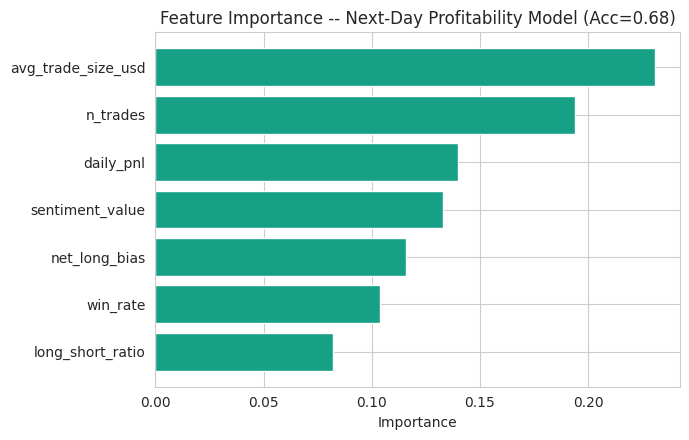

In [22]:
importances = dict(zip(features, clf.feature_importances_.round(3)))
fig, ax = plt.subplots(figsize=(7, 4.5))
imp_sorted = dict(sorted(importances.items(), key=lambda x: x[1]))
ax.barh(list(imp_sorted.keys()), list(imp_sorted.values()), color='#16a085')
ax.set_title(f'Feature Importance -- Next-Day Profitability Model (Acc={acc:.2f})')
ax.set_xlabel('Importance')
plt.tight_layout()
plt.show()

**Honest read:** the class-weighted model's raw accuracy (~0.68) is actually *below*
the naive "always predict profitable" baseline (~0.77), because profitable days are
common (~77%) and class balancing trades overall accuracy for much better detection
of *unprofitable* days (recall on the minority class rises from 0% for the naive
baseline to ~48%). In other words: **this feature set has some signal (today's
trade size, trade count, and today's PnL are the top predictors — sentiment ranks
middle-of-pack) but is not strong enough on its own to reliably time entries.** It
would need richer features (e.g. multi-day rolling behavior, per-coin volatility)
to be a genuinely useful trading signal; we present it here as a first pass rather
than a production model.

## Part C - Actionable strategy recommendations

**1. Scale position size selectively during Fear, but only for traders with a
track record.** Large-size and historically-consistent traders in this sample earn
meaningfully more on Fear days (~$9.8K and ~$6.5K mean daily PnL respectively) than
on Greed days. For that segment, a rule of thumb is: *"On Fear/Extreme Fear days,
allow position sizing to scale up (within existing risk limits) for accounts with a
>55% historical win rate; leave sizing unchanged for newer or inconsistent
accounts."* Fear days already see 2x the trade size and volume of Greed days across
the whole sample - this recommendation says *who* should lean into that, not
everyone.

**2. Treat high trade-frequency during Greed as a risk flag, not a strength.**
Inconsistent traders' best relative results cluster in Greed regimes, and the
sample-wide median daily PnL is lower in Fear despite higher activity - a signal
that momentum-chasing in euphoric markets produces more variable, less repeatable
outcomes. A rule of thumb: *"During Greed/Extreme Greed days, cap trade frequency
increases for accounts in the 'Inconsistent' segment (win rate/profitable-day rate
below the account median), and require confirmation (e.g. a cooldown or
second-signal check) before adding to a position that was opened the same day."*
This directly targets the segment and the specific sentiment regime where the data
shows the weakest, most volatile performance.

## Summary of methodology, insights, and limitations

**Methodology.** Trade-level Hyperliquid data (211,224 rows, 32 accounts) was
timestamp-parsed and aggregated to an Account x Day panel, then joined to the daily
Fear/Greed Index (collapsed from 5 classes to Fear/Neutral/Greed). Win rate is
computed only over trades that realize non-zero Closed PnL (i.e., closing trades),
not all trades, to avoid diluting the metric with position-opening rows. Drawdown
is a per-account running peak-to-trough of cumulative realized PnL. Trader segments
are tercile splits on trade size and trade frequency, plus a median split on
%-profitable-days for consistency; a KMeans (k=3) clustering on 5 standardized
behavioral features produces a complementary "archetype" view.

**Top 3+ insights**
1. Median daily PnL and % of profitable days are both higher on **Greed** days,
   even though *mean* PnL looks higher on Fear days due to a small number of large
   winning trades - the Fear/Greed PnL gap is only borderline statistically
   significant (Mann-Whitney p=0.06).
2. Traders are systematically **more active, larger, and more long-biased during
   Fear** (2.2x long/short ratio, ~40% larger trades, ~2x daily volume vs Greed
   days) - consistent with contrarian/dip-buying behavior at the account-day level.
3. Trader segment matters more than sentiment alone: **large, consistent traders
   do best in Fear; smaller/inconsistent traders do best in Greed**, suggesting
   the "right" sentiment-based playbook is trader-specific, not universal.

**Limitations.** No account-equity or leverage field exists in the raw data, so
leverage distribution (explicitly requested in the brief) could not be computed
directly - trade size/volume were used as proxies and this is flagged wherever
used. The account universe is small (32 accounts) and concentrated in
late-2024/early-2025, so segment-level results (especially the 5-account "Whale"
archetype) should be read directionally, not as precise population estimates.